# Projet 11 — La Poule qui Chante 🐓
## Notebook 2 — ACP, clustering et recommandations
### Segmentation des pays cibles pour l'export de poulet bio

---

**Objectif** : à partir du jeu de données préparé au Notebook 1 (127 pays, 17 variables, standardisées),
réduire la dimension par **ACP**, regrouper les pays par **classification ascendante hiérarchique (CAH)**
puis **k-means**, et en tirer des **recommandations de pays cibles** pour le COMEX.

**Déroulé**
1. Chargement des données
2. ACP — éboulis des valeurs propres et choix du nombre de composantes
3. Cercle des corrélations — interprétation des axes
4. Projection des individus (pays)
5. Classification ascendante hiérarchique (CAH)
6. K-means et nombre optimal de clusters
7. Comparaison CAH ↔ k-means
8. Profils des clusters
9. Recommandations de pays (score composite)
10. Synthèse pour le COMEX + questions de soutenance

## 1. Chargement des données

On charge deux versions produites par le Notebook 1 : le jeu **brut** (pour interpréter les valeurs
réelles) et le jeu **standardisé Z-score** (moyenne 0, écart-type 1) sur lequel on fait l'ACP. Le
centrage-réduction est indispensable : sans lui, les variables à grande échelle (population,
marché) écraseraient les autres dans l'ACP.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")

# ⚙️ À ADAPTER : dossier contenant les CSV du Notebook 1
DATA_DIR = Path("../Raw_data/UtilisésNotebook/")

df  = pd.read_csv(DATA_DIR / "dataset_final.csv")          # brut (interprétation)
dfs = pd.read_csv(DATA_DIR / "dataset_final_scaled.csv")   # standardisé (ACP)
VARS = [c for c in df.columns if c not in ("pays", "code_iso3")]
X = dfs[VARS].values

print(f"{df.shape[0]} pays × {len(VARS)} variables")
print("Vérif standardisation (moyenne≈0, écart-type≈1) :",
      round(np.abs(X.mean(0)).max(), 3), "/", round(np.abs(X.std(0) - 1).max(), 3))

127 pays × 17 variables
Vérif standardisation (moyenne≈0, écart-type≈1) : 0.0 / 0.0


## 2. ACP — éboulis des valeurs propres

**Pourquoi une ACP ?** Nos 17 variables sont partiellement corrélées (richesse, gouvernance et
logistique varient ensemble, par exemple). L'ACP les remplace par un petit nombre de **composantes
non corrélées** qui concentrent l'information : cela supprime la redondance, réduit le bruit, permet
de **visualiser** la structure des pays, et donne un espace plus sain pour le clustering.

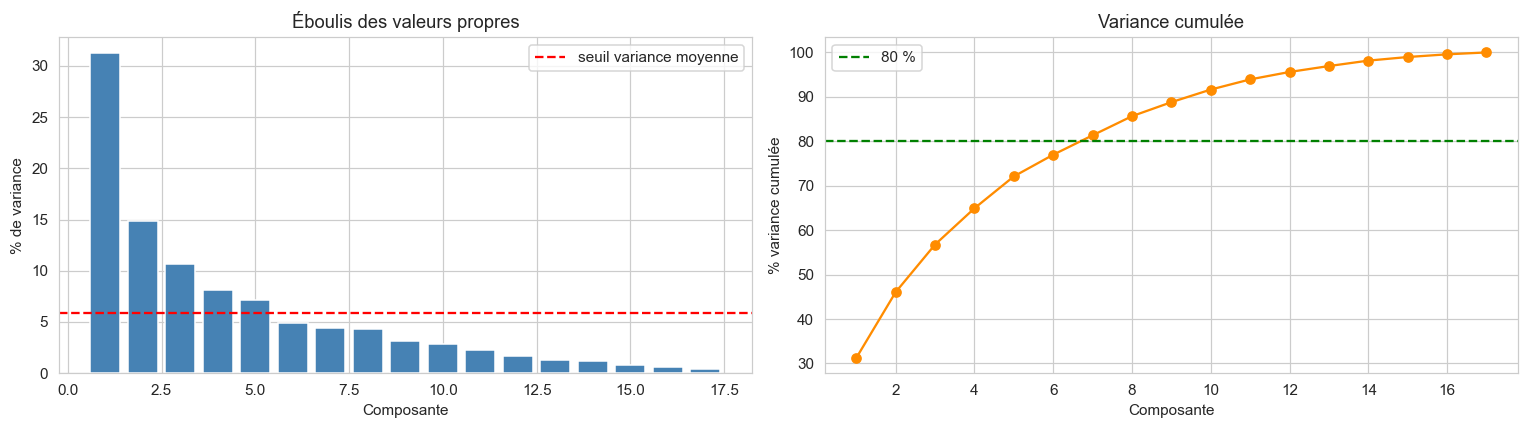

Valeurs propres : [5.35 2.54 1.83 1.4  1.23 0.84 0.75 0.74]
Critère de Kaiser (valeur propre > 1) : 5 composantes → 72.1 % de variance


In [2]:
pca = PCA().fit(X)
eig = pca.explained_variance_                 # valeurs propres
vr  = pca.explained_variance_ratio_ * 100     # % de variance
cum = np.cumsum(vr)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(range(1, len(vr) + 1), vr, color="steelblue")
ax[0].axhline(100 / len(VARS), ls="--", c="red", label="seuil variance moyenne")
ax[0].set(xlabel="Composante", ylabel="% de variance", title="Éboulis des valeurs propres")
ax[0].legend()
ax[1].plot(range(1, len(cum) + 1), cum, "o-", color="darkorange")
ax[1].axhline(80, ls="--", c="green", label="80 %")
ax[1].set(xlabel="Composante", ylabel="% variance cumulée", title="Variance cumulée")
ax[1].legend()
plt.tight_layout(); plt.show()

kaiser = int((eig > 1).sum())
print("Valeurs propres :", np.round(eig[:8], 2))
print(f"Critère de Kaiser (valeur propre > 1) : {kaiser} composantes → {cum[kaiser-1]:.1f} % de variance")

### Choix du nombre de composantes

Trois lectures convergent vers **5 composantes** :
- **Critère de Kaiser** : 5 composantes ont une valeur propre > 1 (elles apportent chacune plus
  d'information qu'une variable d'origine).
- **Coude de l'éboulis** : la pente se casse autour de la 5ᵉ composante.
- Ces 5 composantes retiennent **~72 % de la variance**, ce qui est suffisant pour la structure.

On effectue donc le clustering sur ces **5 composantes** (essayé aussi sur 8 : le clustering y est
moins net). Pour la lecture visuelle, on se concentre sur les tout premiers plans (PC1/PC2, PC1/PC3).

In [3]:
N_COMP = 5                              # critère de Kaiser
pca_n = PCA(n_components=N_COMP).fit(X)
scores = pca_n.transform(X)             # coordonnées des pays dans l'espace ACP
print(f"Espace de travail : {N_COMP} composantes ({cum[N_COMP-1]:.1f} % de variance)")

Espace de travail : 5 composantes (72.1 % de variance)


## 3. Cercle des corrélations

Chaque flèche est une variable ; sa projection sur un axe mesure sa corrélation avec cette composante.
Deux flèches proches = variables corrélées ; flèches opposées = anti-corrélées ; flèche longue =
variable bien représentée sur le plan.

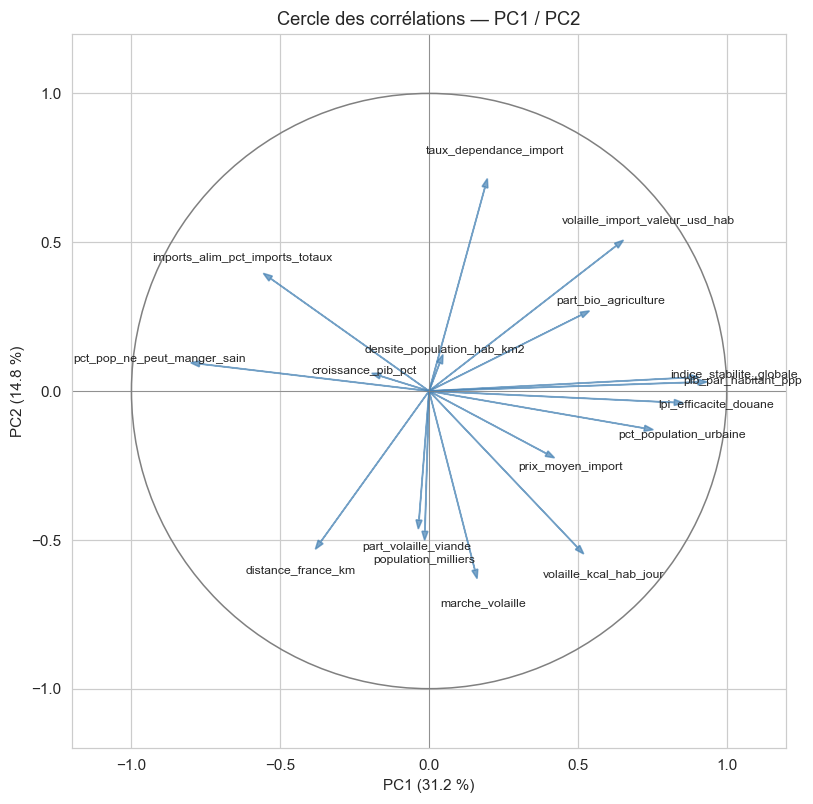

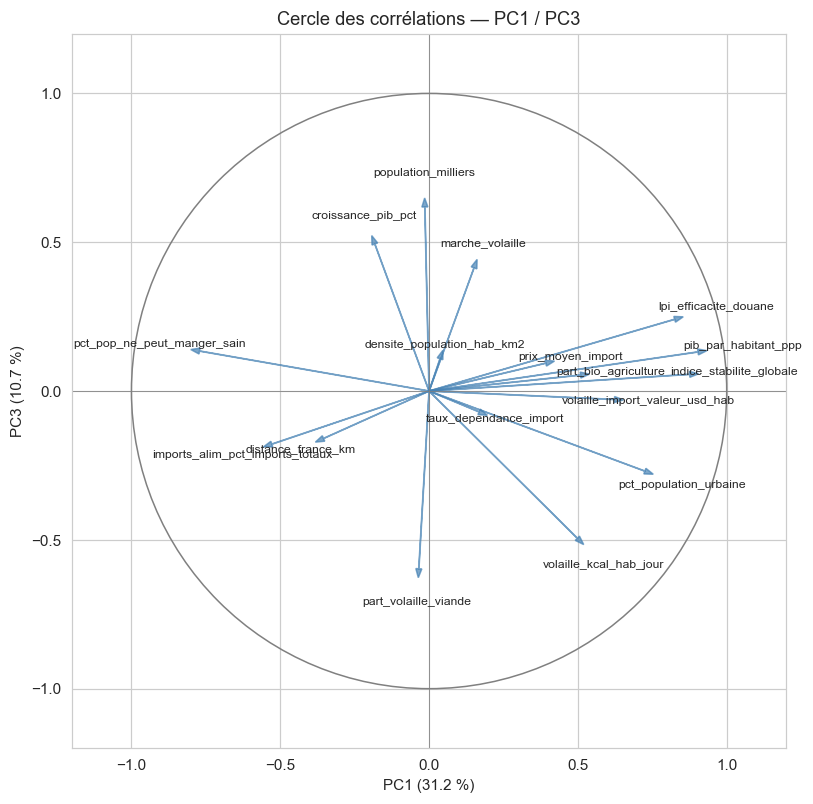

In [4]:
# corrélations variables ↔ composantes
loadings = pca_n.components_.T * np.sqrt(pca_n.explained_variance_)

def cercle_correlations(cx, cy):
    fig, ax = plt.subplots(figsize=(7.5, 7.5))
    ax.add_artist(plt.Circle((0, 0), 1, fill=False, color="grey"))
    for j, v in enumerate(VARS):
        ax.arrow(0, 0, loadings[j, cx], loadings[j, cy],
                 head_width=0.02, color="steelblue", alpha=0.7, length_includes_head=True)
        ax.text(loadings[j, cx] * 1.13, loadings[j, cy] * 1.13, v, fontsize=8, ha="center", va="center")
    ax.axhline(0, c="grey", lw=0.5); ax.axvline(0, c="grey", lw=0.5)
    ax.set(xlim=(-1.2, 1.2), ylim=(-1.2, 1.2),
           xlabel=f"PC{cx+1} ({vr[cx]:.1f} %)", ylabel=f"PC{cy+1} ({vr[cy]:.1f} %)",
           title=f"Cercle des corrélations — PC{cx+1} / PC{cy+1}")
    ax.set_aspect("equal"); plt.tight_layout(); plt.show()

cercle_correlations(0, 1)
cercle_correlations(0, 2)

### Lecture des axes

- **PC1 (≈ 31 %) — axe richesse / développement.** Tirée par le PIB/habitant, la gouvernance,
  l'efficacité des douanes, l'urbanisation, la valeur d'import de volaille par habitant, et
  négativement par la part de population ne pouvant s'offrir une alimentation saine. À droite : pays
  riches, bien gouvernés, bons importateurs ; à gauche : pays pauvres.
- **PC2 (≈ 15 %) — axe taille / dépendance du marché.** Oppose grands marchés autonomes et petits
  marchés dépendants des importations (taux de dépendance, densité).
- **PC3 (≈ 11 %) — axe culture volaille.** Portée par la part de la volaille dans la viande et la
  consommation de volaille par habitant.

*(les signes des axes sont arbitraires en ACP : seule compte l'opposition entre variables.)*

## 4. Projection des individus (pays)

Chaque point est un pays, positionné par ses coordonnées sur PC1/PC2 (codes ISO3 pour la lisibilité).

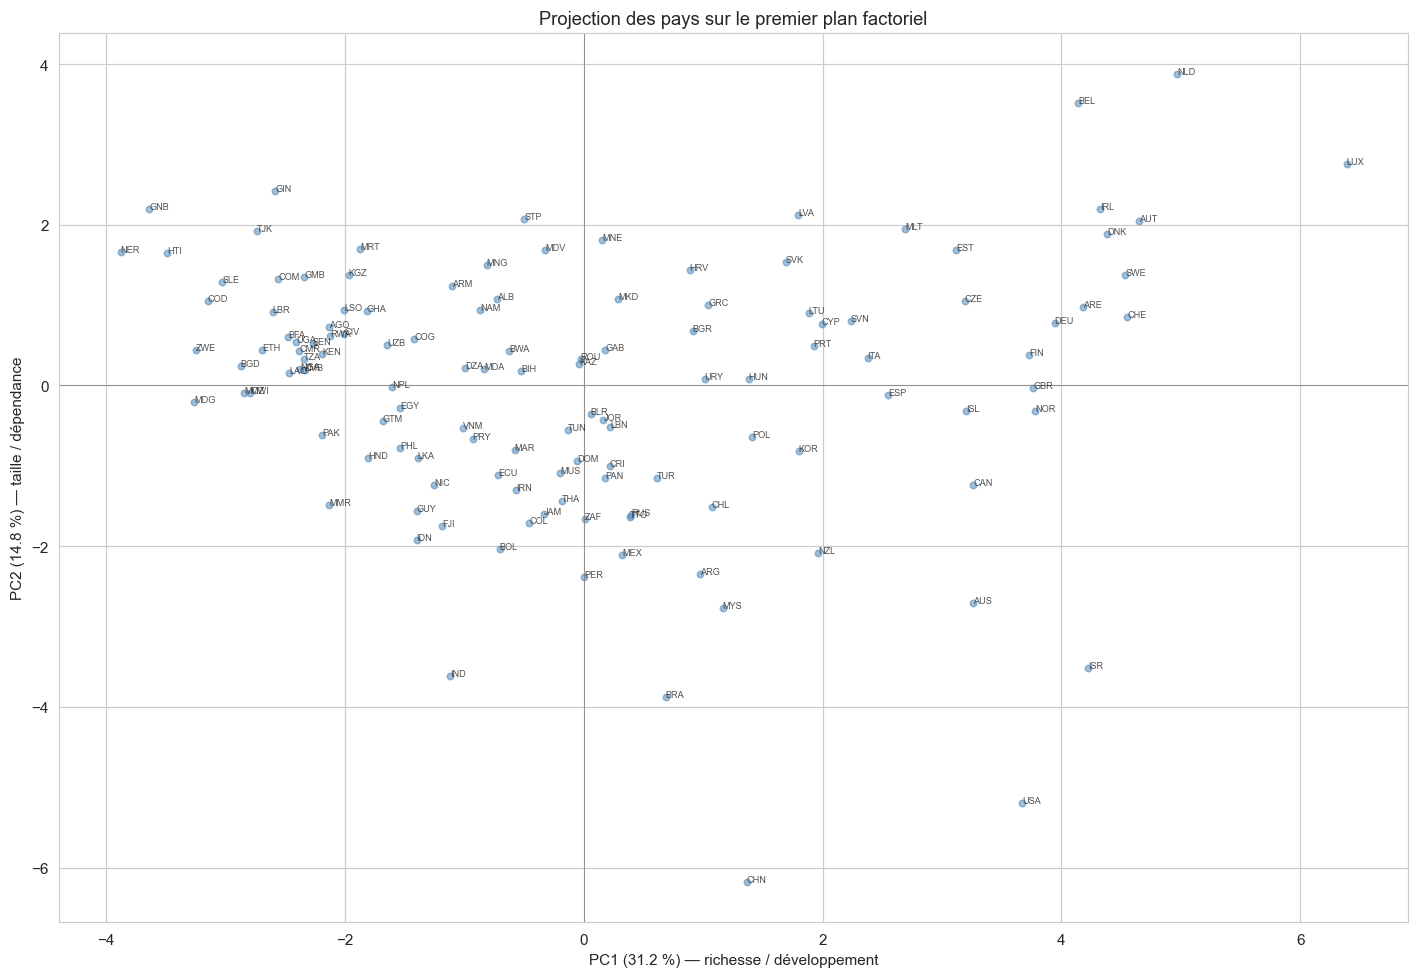

In [5]:
fig, ax = plt.subplots(figsize=(13, 9))
ax.scatter(scores[:, 0], scores[:, 1], s=18, alpha=0.5, color="steelblue")
for i in range(len(df)):
    ax.annotate(df["code_iso3"].iloc[i], (scores[i, 0], scores[i, 1]), fontsize=6, alpha=0.8)
ax.axhline(0, c="grey", lw=0.5); ax.axvline(0, c="grey", lw=0.5)
ax.set(xlabel=f"PC1 ({vr[0]:.1f} %) — richesse / développement",
       ylabel=f"PC2 ({vr[1]:.1f} %) — taille / dépendance",
       title="Projection des pays sur le premier plan factoriel")
plt.tight_layout(); plt.show()

## 5. Classification ascendante hiérarchique (CAH)

On regroupe les pays par la méthode de **Ward** (qui minimise la variance intra-cluster), **sur les
coordonnées ACP** — pas sur les données brutes. Travailler dans l'espace ACP décorrèle les variables
et retire le bruit, ce qui donne des groupes plus stables. Le dendrogramme montre l'arbre des
regroupements ; la hauteur des fusions suggère où couper.

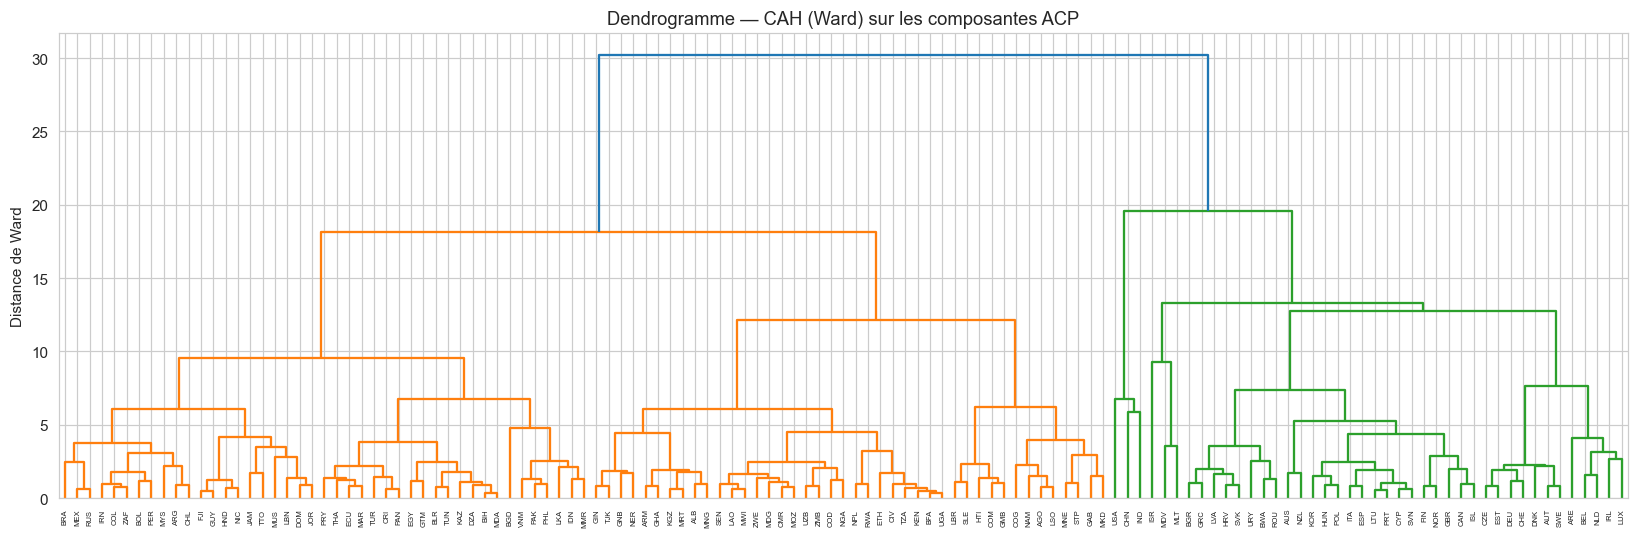

Silhouette de la CAH selon le nombre de clusters :
  k = 2 : silhouette 0.337  | tailles [np.int64(85), np.int64(42)]
  k = 3 : silhouette 0.346  | tailles [np.int64(85), np.int64(39), np.int64(3)]
  k = 4 : silhouette 0.259  | tailles [np.int64(43), np.int64(42), np.int64(39), np.int64(3)]
  k = 5 : silhouette 0.278  | tailles [np.int64(43), np.int64(42), np.int64(36), np.int64(3), np.int64(3)]
  k = 6 : silhouette 0.250  | tailles [np.int64(43), np.int64(42), np.int64(24), np.int64(12), np.int64(3), np.int64(3)]
  k = 7 : silhouette 0.257  | tailles [np.int64(43), np.int64(29), np.int64(24), np.int64(13), np.int64(12), np.int64(3), np.int64(3)]
  k = 8 : silhouette 0.224  | tailles [np.int64(29), np.int64(24), np.int64(22), np.int64(21), np.int64(13), np.int64(12), np.int64(3), np.int64(3)]


In [6]:
Z = linkage(scores, method="ward")

plt.figure(figsize=(15, 5))
dendrogram(Z, labels=df["code_iso3"].values, leaf_font_size=5, color_threshold=0.7 * max(Z[:, 2]))
plt.title("Dendrogramme — CAH (Ward) sur les composantes ACP")
plt.ylabel("Distance de Ward"); plt.tight_layout(); plt.show()

print("Silhouette de la CAH selon le nombre de clusters :")
for k in range(2, 9):
    lab = fcluster(Z, k, criterion="maxclust")
    print(f"  k = {k} : silhouette {silhouette_score(scores, lab):.3f}  | tailles {sorted(np.bincount(lab)[1:], reverse=True)}")

cah = fcluster(Z, 5, criterion="maxclust")

## 6. K-means et nombre optimal de clusters

Deux repères pour choisir *k* : la **méthode du coude** (inertie intra-cluster) et l'**indice de
silhouette**. La silhouette favorise souvent très peu de groupes (k = 2 : riches vs pauvres), trop
grossier pour cibler. On retient **k = 5** : un bon compromis entre qualité statistique et
**granularité utile au business** (5 segments actionnables), cohérent avec la coupe du dendrogramme.

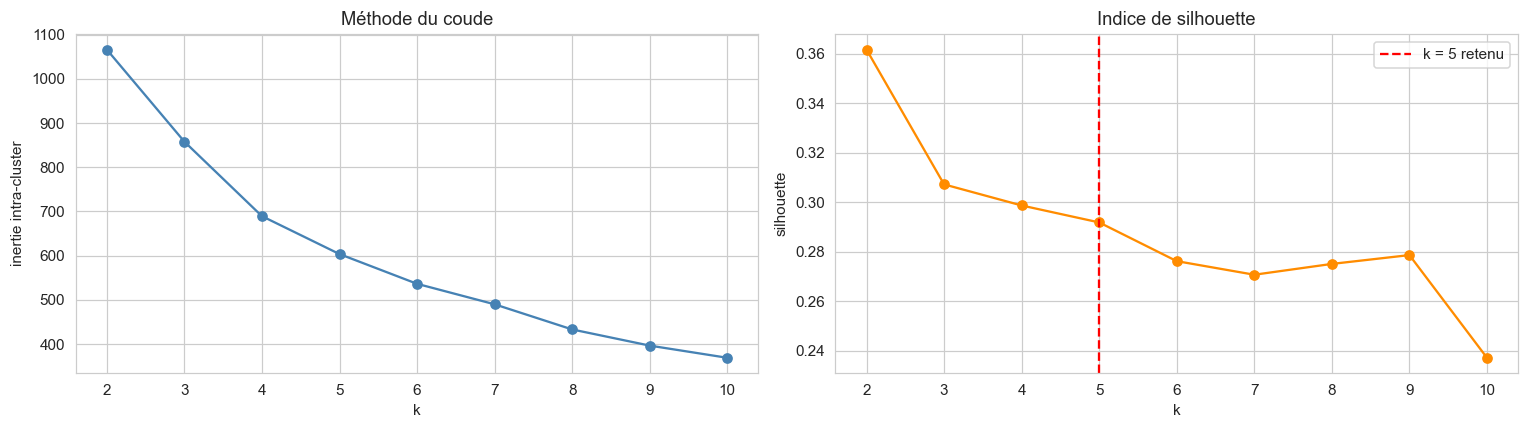

Silhouette k-means (k=5) : 0.292
Tailles des clusters : {1: np.int64(28), 2: np.int64(48), 3: np.int64(41), 4: np.int64(3), 5: np.int64(7)}


In [7]:
Ks = range(2, 11)
inerties, silhouettes = [], []
for k in Ks:
    m = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scores)
    inerties.append(m.inertia_)
    silhouettes.append(silhouette_score(scores, m.labels_))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(list(Ks), inerties, "o-", color="steelblue")
ax[0].set(xlabel="k", ylabel="inertie intra-cluster", title="Méthode du coude")
ax[1].plot(list(Ks), silhouettes, "o-", color="darkorange")
ax[1].axvline(5, ls="--", c="red", label="k = 5 retenu")
ax[1].set(xlabel="k", ylabel="silhouette", title="Indice de silhouette"); ax[1].legend()
plt.tight_layout(); plt.show()

K = 5
km = KMeans(n_clusters=K, random_state=42, n_init=10).fit_predict(scores) + 1
df["cluster"] = km
print(f"Silhouette k-means (k={K}) : {silhouette_score(scores, km):.3f}")
print("Tailles des clusters :", dict(pd.Series(km).value_counts().sort_index()))

## 7. Comparaison CAH ↔ k-means

L'**ARI (Adjusted Rand Index)** mesure l'accord entre les deux partitions (1 = identiques, 0 =
aléatoire).

In [8]:
ari = adjusted_rand_score(cah, km)
print(f"ARI (CAH vs k-means) = {ari:.3f}")
print("\nTable de correspondance (lignes = CAH, colonnes = k-means) :")
print(pd.crosstab(pd.Series(cah, name="CAH"), pd.Series(km, name="k-means")))

ARI (CAH vs k-means) = 0.653

Table de correspondance (lignes = CAH, colonnes = k-means) :
k-means   1   2   3  4  5
CAH                      
1         0   6  37  0  0
2         0  39   3  0  0
3         0   0   0  3  0
4         1   1   0  0  1
5        27   2   1  0  6


**Pourquoi les deux méthodes ne donnent-elles pas exactement le même résultat ?** Elles ne
regroupent pas de la même façon : la **CAH** construit un arbre par fusions successives (déterministe,
une fois l'arbre fixé) ; le **k-means** part de centres tirés au hasard et déplace chaque pays vers le
centre le plus proche par itérations. Sur le cœur des clusters, les deux s'accordent fortement (ARI
élevé) ; les écarts portent sur les **pays-frontières**, dont l'affectation est intrinsèquement peu
robuste (silhouette modérée). C'est pourquoi on s'appuiera surtout sur le **classement composite**
pour la recommandation, et sur les **profils** de clusters plutôt que sur l'appartenance exacte d'un
pays donné.

## 8. Profils des clusters

On décrit chaque groupe par la **moyenne** de ses variables clés (sur les valeurs brutes), puis on
lui donne un nom métier. Le nommage est calculé **à partir des profils** (robuste au numéro de
cluster).

In [9]:
cols_show = ["pib_par_habitant_ppp", "volaille_kcal_hab_jour", "population_milliers",
             "taux_dependance_import", "part_bio_agriculture", "indice_stabilite_globale"]
profil = (df.groupby("cluster").agg(n=("pays", "size")).join(df.groupby("cluster")[cols_show].mean())).round(1)
print("=== PROFIL DES CLUSTERS ===")
print(profil.to_string())

# nommage métier automatique (par profil, indépendant du numéro)
p = df.groupby("cluster").agg(pib=("pib_par_habitant_ppp", "mean"),
                              pop=("population_milliers", "mean"), n=("pays", "size"))
noms = {}
g = p["pop"].idxmax();                         noms[g] = "Géants autosuffisants"
r = p.drop(g)
e = r[r["n"] <= 12]["pib"].idxmax();           noms[e] = "Hubs ultra-premium (réexport)"
r = r.drop(e)
pr = r["pib"].idxmax();                         noms[pr] = "Marchés développés premium"
r = r.drop(pr)
po = r["pib"].idxmin();                         noms[po] = "Pays pauvres (hors cible)"
noms[r.drop(po).index[0]] = "Marchés intermédiaires (forte conso volaille)"

df["cluster_nom"] = df["cluster"].map(noms)
print("\n=== NOMS DES CLUSTERS ===")
for c in sorted(noms): print(f"  Cluster {c} : {noms[c]}  ({(df['cluster']==c).sum()} pays)")

=== PROFIL DES CLUSTERS ===
          n  pib_par_habitant_ppp  volaille_kcal_hab_jour  population_milliers  taux_dependance_import  part_bio_agriculture  indice_stabilite_globale
cluster                                                                                                                                               
1        28               47789.5                    96.3              18690.4                     0.3                   0.1                      75.2
2        48                7003.4                    24.8              35940.2                     0.4                   0.0                      45.0
3        41               18071.0                   111.2              36470.8                     0.2                   0.0                      50.7
4         3               48188.7                    89.6            1034738.9                     0.0                   0.0                      61.4
5         7               75657.1                    82.2         

In [10]:
# Membres des petits clusters (les plus stratégiques)
for c in sorted(df["cluster"].unique()):
    membres = sorted(df[df["cluster"] == c]["pays"].tolist())
    if len(membres) <= 10:
        print(f"Cluster {c} — {noms[c]} :")
        print("   ", ", ".join(membres), "\n")

Cluster 4 — Géants autosuffisants :
    China, mainland, India, United States of America 

Cluster 5 — Hubs ultra-premium (réexport) :
    Belgium, Denmark, Ireland, Luxembourg, Malta, Netherlands (Kingdom of the), United Arab Emirates 



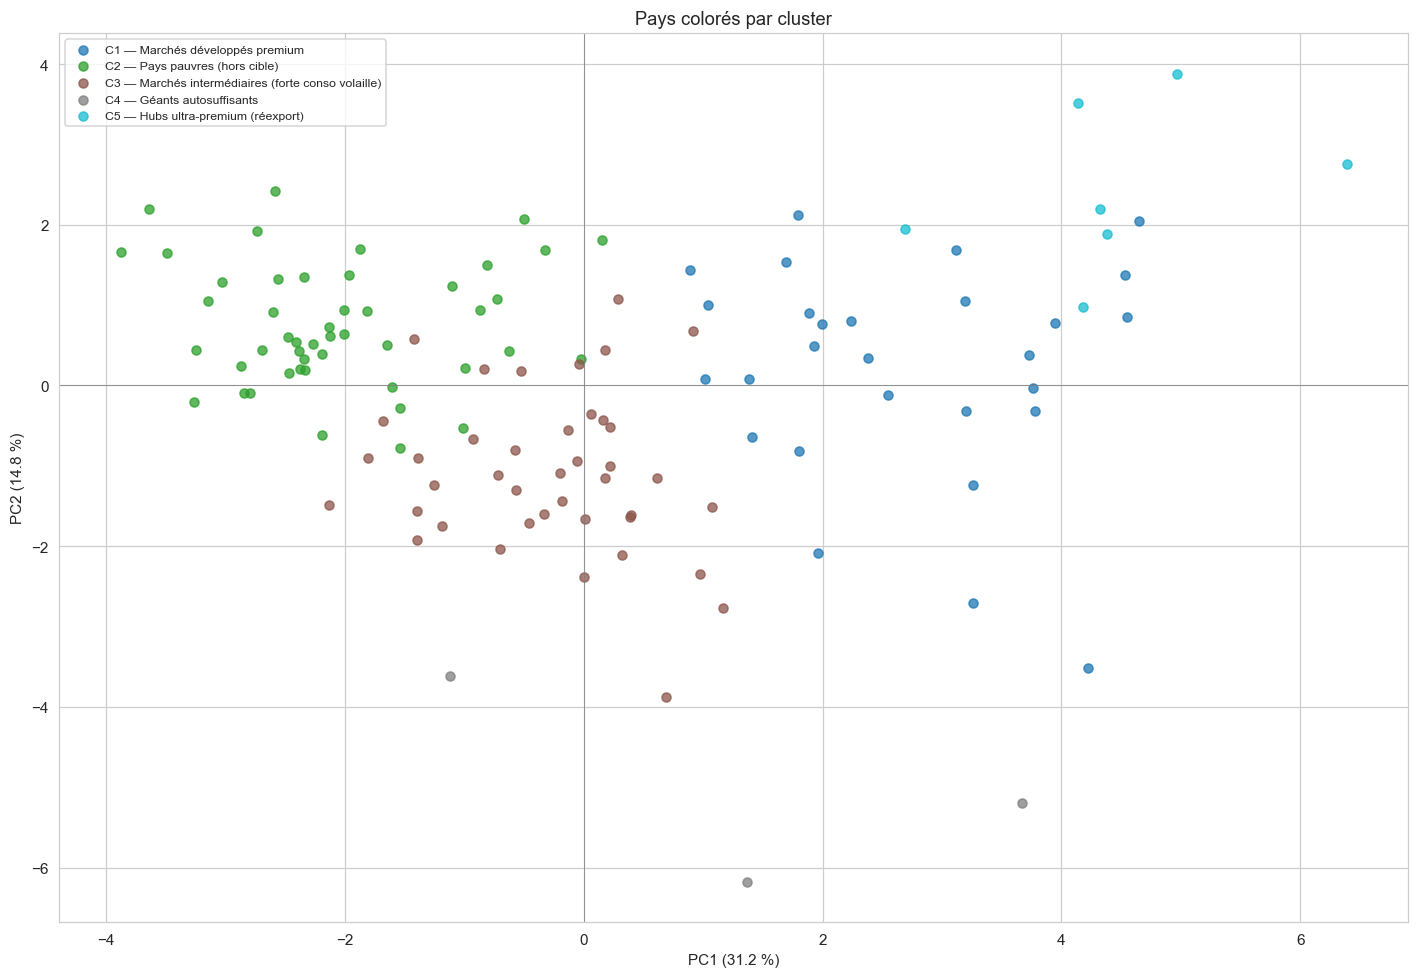

In [11]:
# Projection des pays colorés par cluster
fig, ax = plt.subplots(figsize=(13, 9))
palette = plt.cm.tab10(np.linspace(0, 1, df["cluster"].nunique()))
for col, c in zip(palette, sorted(df["cluster"].unique())):
    m = df["cluster"] == c
    ax.scatter(scores[m, 0], scores[m, 1], s=35, color=col, alpha=0.75, label=f"C{c} — {noms[c]}")
ax.axhline(0, c="grey", lw=0.5); ax.axvline(0, c="grey", lw=0.5)
ax.set(xlabel=f"PC1 ({vr[0]:.1f} %)", ylabel=f"PC2 ({vr[1]:.1f} %)",
       title="Pays colorés par cluster")
ax.legend(fontsize=8, loc="best"); plt.tight_layout(); plt.show()

## 9. Recommandations de pays cibles

Le clustering décrit *où* se situent les opportunités ; pour **classer** les pays d'un même groupe
premium, on construit un **score composite** pondéré selon les priorités métier d'un producteur bio
premium :

| Variable | Poids | Logique |
|---|---|---|
| PIB/habitant PPA | 30 % | pouvoir d'achat pour un produit premium |
| Taux de dépendance import | 25 % | besoin d'importer de la volaille |
| Prix moyen à l'import | 20 % | marché déjà positionné haut de gamme |
| Part de l'agriculture bio | 15 % | maturité du marché bio |
| Efficacité des douanes | 10 % | logistique d'un produit périssable |

**Garde-fou** : le score seul peut faire remonter des **micro-marchés** (fort taux de dépendance mais
population et PIB minuscules → marché total dérisoire). On ajoute donc un **plancher de matérialité** :
marché total (population × PIB/hab) ≥ 10 Md$. Ce seuil écarte les micro-marchés type São Tomé tout en
gardant les petits pays riches (Luxembourg, Malte).

In [12]:
COLS = ["pib_par_habitant_ppp", "taux_dependance_import", "prix_moyen_import",
        "part_bio_agriculture", "lpi_efficacite_douane"]
POIDS = np.array([0.30, 0.25, 0.20, 0.15, 0.10])

df["score_composite"] = (MinMaxScaler().fit_transform(df[COLS]) * POIDS).sum(axis=1)
df["marche_total_mds$"] = df["population_milliers"] * df["pib_par_habitant_ppp"] / 1e6

SEUIL_MDS = 10
eligibles = df[df["marche_total_mds$"] >= SEUIL_MDS].copy()
ecartes = sorted(set(df["pays"]) - set(eligibles["pays"]))
print(f"{len(ecartes)} pays écartés par le plancher de matérialité (marché < {SEUIL_MDS} Md$).")

reco = eligibles.sort_values("score_composite", ascending=False)
print("\n=== TOP 15 PAYS CIBLES ===")
print(reco[["pays", "cluster_nom", "score_composite", "taux_dependance_import",
            "marche_total_mds$"]].head(15).round(2).to_string(index=False))

8 pays écartés par le plancher de matérialité (marché < 10 Md$).

=== TOP 15 PAYS CIBLES ===
                        pays                   cluster_nom  score_composite  taux_dependance_import  marche_total_mds$
                  Luxembourg Hubs ultra-premium (réexport)             0.59                    1.09              78.84
Netherlands (Kingdom of the) Hubs ultra-premium (réexport)             0.54                    2.10            1137.03
                     Belgium Hubs ultra-premium (réexport)             0.52                    2.01             666.16
                     Austria    Marchés développés premium             0.49                    0.64             550.91
                      Sweden    Marchés développés premium             0.44                    0.45             602.30
                 Switzerland    Marchés développés premium             0.42                    0.39             656.23
                     Denmark Hubs ultra-premium (réexport)             0.4

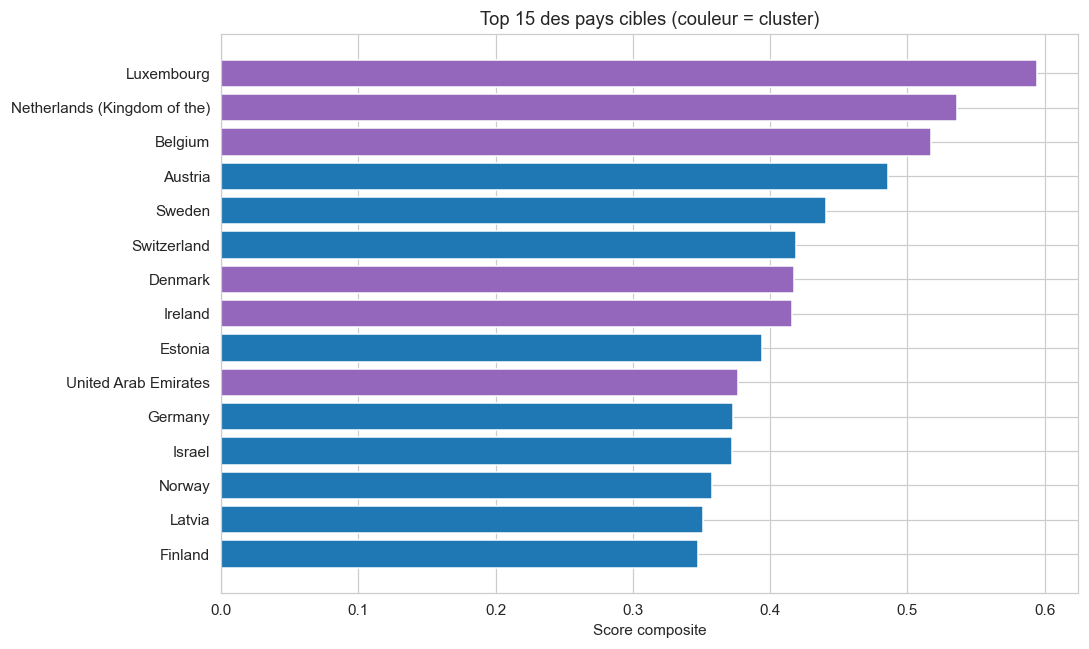

In [13]:
# Visualisation : score composite des 15 premiers, colorés par cluster
top = reco.head(15).iloc[::-1]
plt.figure(figsize=(10, 6))
colmap = {c: plt.cm.tab10(i) for i, c in enumerate(sorted(df["cluster"].unique()))}
plt.barh(top["pays"], top["score_composite"], color=[colmap[c] for c in top["cluster"]])
plt.xlabel("Score composite"); plt.title("Top 15 des pays cibles (couleur = cluster)")
plt.tight_layout(); plt.show()

## 10. Synthèse pour le COMEX

**Ce qu'on a fait, sans jargon.** On a réuni pour ~127 pays 17 indicateurs (richesse, consommation de
volaille, dépendance aux imports, gouvernance, logistique, maturité bio…). L'**ACP** résume ces 17
indicateurs en quelques « grands facteurs » (surtout : la richesse/développement, la taille/dépendance
du marché, la culture volaille). On a ensuite **regroupé les pays qui se ressemblent** en 5 familles,
et **classé** les plus prometteurs.

**Les 5 familles de pays.**
- **Marchés développés premium** — riches, stables, matures sur le bio : le cœur de cible.
- **Hubs ultra-premium (réexport)** — très riches et très importateurs (Belgique, Pays-Bas,
  Luxembourg, Irlande, UAE, Malte, Danemark) : petits mais à très forte valeur.
- **Marchés intermédiaires** — gros consommateurs de volaille mais plutôt autosuffisants.
- **Géants** — Chine, Inde, USA : énormes mais quasi autosuffisants (autre logique d'entrée).
- **Pays pauvres** — hors cible pour un produit premium.

**Recommandation.** Cibler en priorité les **hubs ultra-premium** et les **marchés développés
premium**. En tête du classement composite : **Luxembourg, Pays-Bas, Belgique, Autriche, Suède,
Suisse, Danemark, Irlande**, puis les Émirats arabes unis et l'Allemagne. Ces pays combinent pouvoir
d'achat, besoin d'importer, positionnement premium et appétence bio.

### Réponses aux questions probables du COMEX / de la soutenance

**Y a-t-il un pays qui ressort ?** Le **Luxembourg** arrive en tête du score composite (très riche,
importateur, premium). Mais la recommandation robuste n'est pas *un* pays : c'est un **groupe** — les
hubs ultra-premium (Belgique, Pays-Bas, Irlande, UAE…) et les marchés développés premium.

**En quoi l'ACP est-elle utile ?** Elle supprime la redondance entre variables corrélées, réduit la
dimension (17 → 5 facteurs), retire le bruit et permet de visualiser et de clusteriser les pays dans
un espace sain.

**Combien de variables synthétiques a-t-on gardées ?** **5 composantes** (critère de Kaiser : valeur
propre > 1), soit ~72 % de l'information d'origine.

**Faut-il clusteriser sur les données réelles ou sur l'ACP ?** Sur les **composantes ACP** : elles
sont décorrélées et débruitées, ce qui rend les groupes plus stables et évite qu'une variable pèse
double via ses corrélées.

**CAH et k-means donnent-elles le même résultat ?** Largement le même cœur (ARI élevé), mais pas à
l'identique : elles diffèrent sur les pays-frontières. D'où le fait qu'on s'appuie sur le classement
composite et les profils, pas sur l'étiquette exacte d'un pays.

**Quel est le nombre optimal de clusters ?** **5**. La silhouette privilégierait 2 groupes
(riches/pauvres), trop grossier ; 5 offre une segmentation actionnable tout en gardant une bonne
qualité, en accord avec le dendrogramme.

**Limite à assumer.** À ce niveau de séparation (silhouette ~0,3), l'appartenance d'un pays isolé à un
cluster n'est pas garantie ; la reco s'appuie donc sur le **classement** et les **profils**, plus
robustes.